# Overview of data
JEPXは翌日の任意の30分間における1kWhの値段を表した時系列データで、未来の需給の期待値となっている。

例えば、3月31日の10:00-10:30の価格は3月30日の午後までに入札がされて決定される

正確な定義
>JEPX価格とは、
前日に行われた入札に基づいて決定される、
翌日の各30分時間帯における
電力1kWhあたりの市場クリアリング価格である。

## 概要
- 2021年から2024年までのデータを結合して分析する
- データを1week平均にする
- 正規分布と対数正規分布でフィッティングし、どちらの分布が価格の分布をよりよく表すかを評価する
- 価格の自己相関、偏自己相関を計算して自己回帰の次数を決定する

In [1]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = (
    REPO_ROOT
    / "One_week_ahead_electricity_price_forecasting_using_weather_forecasts_and_its_application_to_arbitrage_in_the_forward_market_an_empirical_study_of_the_JEPX"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels
import scipy

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.9.4
scipy: 1.17.1
statsmodels: 0.14.6


In [2]:
# 2021〜2024 を結合
dfs = []

for year in range(2021, 2025):
    csv_path = RAW_DATA_DIR / f"electricity/spot_summary_{year}.csv"

    df_year = pd.read_csv(csv_path, encoding="cp932")

    # 年度情報を追加
    df_year["year"] = year

    dfs.append(df_year)

# 縦結合
df = pd.concat(dfs, ignore_index=True)

# 確認
print(df.shape)
df.head()

(70128, 20)


,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
0,2021/04/01,1,18858000,18427950,15407900,5.63,6.29,6.29,6.29,6.29,6.29,6.29,6.29,6.29,5.63,6444650,3118150,1311300,690100,2021
1,2021/04/01,2,20478700,18642200,15601200,5.63,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.63,7948350,3286600,1579900,874050,2021
2,2021/04/01,3,20969850,18695200,15724850,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,8382200,3364500,1777050,1071100,2021
3,2021/04/01,4,21238500,18648700,15674700,5.49,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,8609750,3274500,1826200,1120100,2021
4,2021/04/01,5,21479350,18600100,15639400,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,8813050,3195100,1890350,1173200,2021


In [3]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
70123,2025/03/31,44,20735800,18888600,14692550,13.78,14.06,14.06,14.06,13.80,13.80,13.80,13.80,8.62,13.80,4731600,697200,1427200,1364700,2024
70124,2025/03/31,45,20233050,19114000,14319300,13.78,14.58,14.58,14.58,14.58,14.58,14.58,14.58,8.65,14.58,4723500,667600,1573100,1417300,2024
70125,2025/03/31,46,20149300,18782600,13947850,13.54,14.09,14.09,14.09,13.70,13.70,13.70,13.70,8.57,13.70,4774950,754000,1374650,1218850,2024
70126,2025/03/31,47,19815900,18495300,13795200,13.49,13.98,13.98,13.98,13.53,13.53,13.53,13.53,8.59,13.53,4654550,738600,1198200,1042600,2024
70127,2025/03/31,48,19737800,17754000,13697150,13.09,13.52,13.52,13.52,12.57,12.57,12.57,12.57,8.57,12.57,4294900,806200,1095700,943450,2024


In [4]:
# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])

# 時刻コード → 30分刻み
df["datetime"] = df["受渡日"] + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")

# indexに設定
df = df.set_index("datetime").sort_index()
df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2021-04-01 00:00:00,2021-04-01,1,18858000,18427950,15407900,5.63,6.29,6.29,6.29,6.29,6.29,6.29,6.29,6.29,5.63,6444650,3118150,1311300,690100,2021
2021-04-01 00:30:00,2021-04-01,2,20478700,18642200,15601200,5.63,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.68,5.63,7948350,3286600,1579900,874050,2021
2021-04-01 01:00:00,2021-04-01,3,20969850,18695200,15724850,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,5.49,8382200,3364500,1777050,1071100,2021
2021-04-01 01:30:00,2021-04-01,4,21238500,18648700,15674700,5.49,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,5.39,8609750,3274500,1826200,1120100,2021
2021-04-01 02:00:00,2021-04-01,5,21479350,18600100,15639400,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,5.56,8813050,3195100,1890350,1173200,2021


In [5]:
df.tail()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh),year
datetime,,,,,,,,,,,,,,,,,,,,
2025-03-31 21:30:00,2025-03-31,44,20735800,18888600,14692550,13.78,14.06,14.06,14.06,13.80,13.80,13.80,13.80,8.62,13.80,4731600,697200,1427200,1364700,2024
2025-03-31 22:00:00,2025-03-31,45,20233050,19114000,14319300,13.78,14.58,14.58,14.58,14.58,14.58,14.58,14.58,8.65,14.58,4723500,667600,1573100,1417300,2024
2025-03-31 22:30:00,2025-03-31,46,20149300,18782600,13947850,13.54,14.09,14.09,14.09,13.70,13.70,13.70,13.70,8.57,13.70,4774950,754000,1374650,1218850,2024
2025-03-31 23:00:00,2025-03-31,47,19815900,18495300,13795200,13.49,13.98,13.98,13.98,13.53,13.53,13.53,13.53,8.59,13.53,4654550,738600,1198200,1042600,2024
2025-03-31 23:30:00,2025-03-31,48,19737800,17754000,13697150,13.09,13.52,13.52,13.52,12.57,12.57,12.57,12.57,8.57,12.57,4294900,806200,1095700,943450,2024


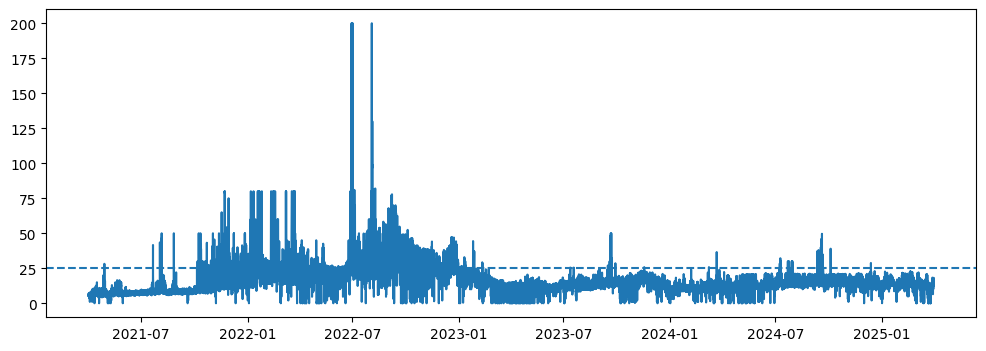

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df["エリアプライス東京(円/kWh)"])
plt.axhline(y=25, linestyle="--")
plt.show()

# Weekly average price distribution

## Base

東京プライスを用いて図1の再現を実施

weekly average price has a left-skewed distribution and is closer to the lognormal distribution

left-skewはおかしいのでright-skewが妥当

In [7]:
price_col = "エリアプライス東京(円/kWh)"

df_base = df[[price_col]].copy()

weekly_base = df_base.resample("W").mean()
len(weekly_base)

210

In [8]:
weekly_base.skew()
# skew > 0 より、右袖に長い分布ということがわかる

エリアプライス東京(円/kWh)    1.548904
dtype: float64

In [9]:
weekly_base.head()

,エリアプライス東京(円/kWh)
datetime,
2021-04-04,5.795625
2021-04-11,6.433869
2021-04-18,7.525089
2021-04-25,6.892857
2021-05-02,7.954732


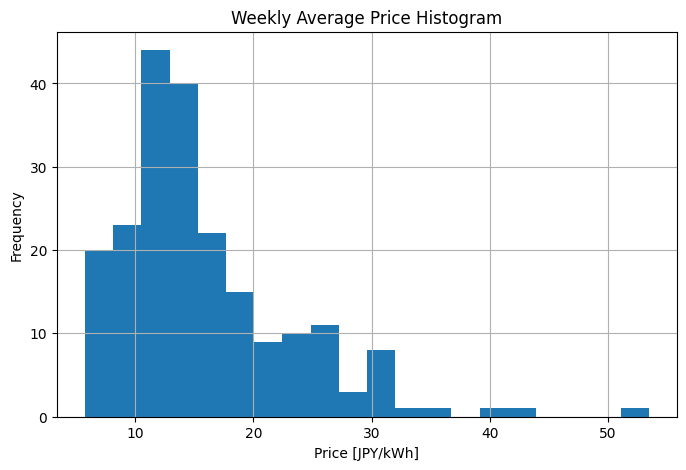

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(weekly_base, bins=20)

plt.title("Weekly Average Price Histogram")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

The weekly average price is closer to the lognormal distribution than the normal distribution

In [11]:
from scipy.stats import norm, lognorm

Normal
mu    = 15.8764
sigma = 7.3248
logLik = -716.1435
AIC    = 1436.2870

Lognormal
shape = 0.4201
loc   = 0.0000
scale = 14.4863
logLik = -677.2269
AIC    = 1358.4538

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


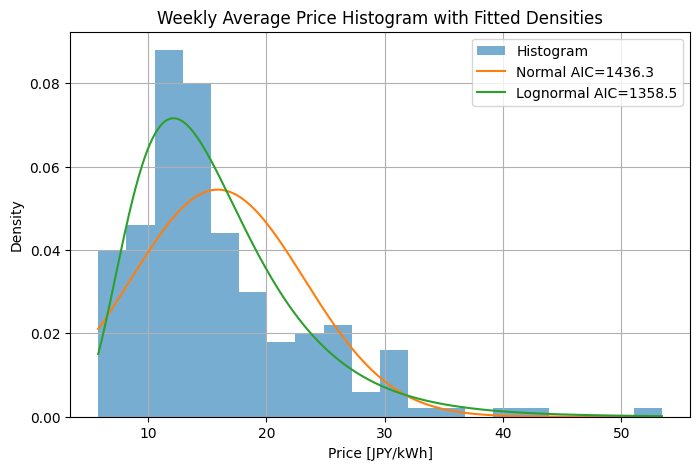

In [12]:
# -----------------------------
# データを1次元配列にする
# -----------------------------
x = weekly_base.squeeze().dropna().values

# 価格は正の値だけ使う
x = x[x > 0]

# -----------------------------
# 1. Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)

loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2  # mu, sigma
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# 2. Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(x, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
)

k_lognorm = 2  # shape, scale。locは floc=0 で固定しているので数えない
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# 3. 結果表示
# -----------------------------
print("Normal")
print(f"mu    = {mu_norm:.4f}")
print(f"sigma = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()

print("Lognormal")
print(f"shape = {shape_lognorm:.4f}")
print(f"loc   = {loc_lognorm:.4f}")
print(f"scale = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()

if aic_lognorm < aic_norm:
    print(
        "AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。"
    )
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# 4. ヒストグラム + fitted density
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(xs, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)

plt.figure(figsize=(8, 5))

plt.hist(x, bins=20, density=True, alpha=0.6, label="Histogram")

plt.plot(xs, pdf_norm, label=f"Normal AIC={aic_norm:.1f}")

plt.plot(xs, pdf_lognorm, label=f"Lognormal AIC={aic_lognorm:.1f}")

plt.title("Weekly Average Price Histogram with Fitted Densities")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

## Daytime 
日中8:00から18:00に限った話

In [13]:
price_col = "エリアプライス東京(円/kWh)"

# -----------------------------
# daytime data
# 平日 08:00-18:00
# -----------------------------
df_daytime = df[[price_col]].copy()

# 平日だけ
df_daytime = df_daytime[df_daytime.index.weekday < 5]

# 08:00-18:00
df_daytime = df_daytime.between_time("08:00", "18:00")

# -----------------------------
# weekly average
# -----------------------------
weekly_daytime = df_daytime.resample("W").mean()

weekly_daytime.head()

,エリアプライス東京(円/kWh)
datetime,
2021-04-04,5.603095
2021-04-11,5.997619
2021-04-18,7.768857
2021-04-25,6.017333
2021-05-02,8.294667


Daytime weekly average price
skewness = 2.4936

Normal
mu     = 17.6192
sigma  = 10.3927
logLik = -789.6093
AIC    = 1583.2186

Lognormal
shape  = 0.4961
loc    = 0.0000
scale  = 15.4545
logLik = -725.7188
AIC    = 1455.4375

AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。


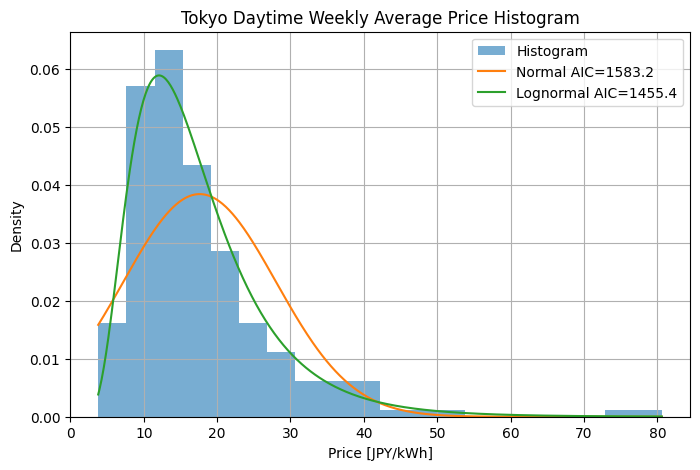

In [14]:
# -----------------------------
# Daytime weekly data
# -----------------------------
x = weekly_daytime.squeeze().dropna().values
x = x[x > 0]

# -----------------------------
# Skewness
# -----------------------------
skew_value = pd.Series(x).skew()

print("Daytime weekly average price")
print(f"skewness = {skew_value:.4f}")

# -----------------------------
# Normal fit
# -----------------------------
mu_norm, sigma_norm = norm.fit(x)
loglik_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))

k_norm = 2
aic_norm = 2 * k_norm - 2 * loglik_norm

# -----------------------------
# Lognormal fit
# -----------------------------
shape_lognorm, loc_lognorm, scale_lognorm = lognorm.fit(x, floc=0)

loglik_lognorm = np.sum(
    lognorm.logpdf(x, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)
)

k_lognorm = 2
aic_lognorm = 2 * k_lognorm - 2 * loglik_lognorm

# -----------------------------
# Result
# -----------------------------
print()
print("Normal")
print(f"mu     = {mu_norm:.4f}")
print(f"sigma  = {sigma_norm:.4f}")
print(f"logLik = {loglik_norm:.4f}")
print(f"AIC    = {aic_norm:.4f}")

print()
print("Lognormal")
print(f"shape  = {shape_lognorm:.4f}")
print(f"loc    = {loc_lognorm:.4f}")
print(f"scale  = {scale_lognorm:.4f}")
print(f"logLik = {loglik_lognorm:.4f}")
print(f"AIC    = {aic_lognorm:.4f}")

print()
if aic_lognorm < aic_norm:
    print(
        "AICは Lognormal の方が小さいです。対数正規分布の方がよくフィットしています。"
    )
else:
    print("AICは Normal の方が小さいです。正規分布の方がよくフィットしています。")

# -----------------------------
# Plot
# -----------------------------
xs = np.linspace(x.min(), x.max(), 500)

pdf_norm = norm.pdf(xs, loc=mu_norm, scale=sigma_norm)

pdf_lognorm = lognorm.pdf(xs, s=shape_lognorm, loc=loc_lognorm, scale=scale_lognorm)

plt.figure(figsize=(8, 5))

plt.hist(x, bins=20, density=True, alpha=0.6, label="Histogram")

plt.plot(xs, pdf_norm, label=f"Normal AIC={aic_norm:.1f}")

plt.plot(xs, pdf_lognorm, label=f"Lognormal AIC={aic_lognorm:.1f}")

plt.title("Tokyo Daytime Weekly Average Price Histogram")
plt.xlabel("Price [JPY/kWh]")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

そもそもだが2022年は別市場に見えるくらい価格の変化が激しい

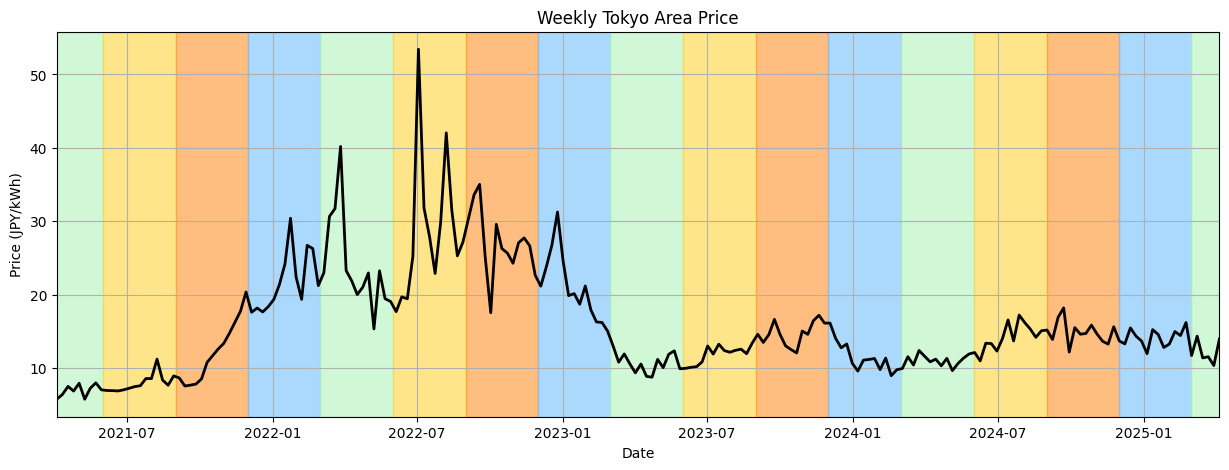

In [15]:
# 時系列プロット
fig, ax = plt.subplots(figsize=(15, 5))

season_colors = {
    "spring": "#b2f2bb",  # 黄緑
    "summer": "#ffd43b",  # 黄色
    "autumn": "#ff922b",  # オレンジ
    "winter": "#74c0fc",  # 水色
}

years = range(weekly_base.index.min().year, weekly_base.index.max().year + 1)

for year in years:
    seasons = [
        ("spring", f"{year}-03-01", f"{year}-06-01"),
        ("summer", f"{year}-06-01", f"{year}-09-01"),
        ("autumn", f"{year}-09-01", f"{year}-12-01"),
        ("winter", f"{year}-12-01", f"{year + 1}-03-01"),
    ]

    for season, start, end in seasons:
        ax.axvspan(
            pd.to_datetime(start),
            pd.to_datetime(end),
            color=season_colors[season],
            alpha=0.6,
        )

# 折れ線
ax.plot(
    weekly_base.index,
    weekly_base["エリアプライス東京(円/kWh)"],
    linewidth=2,
    color="black",
)

# データ範囲に合わせる
ax.set_xlim(weekly_base.index.min(), weekly_base.index.max())

ax.set_title("Weekly Tokyo Area Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (JPY/kWh)")
ax.grid(True)

plt.show()

In [16]:
weekly_base = weekly_base.rename(columns={"エリアプライス東京(円/kWh)": "tokyo_price"})

weekly_base.head()

,tokyo_price
datetime,
2021-04-04,5.795625
2021-04-11,6.433869
2021-04-18,7.525089
2021-04-25,6.892857
2021-05-02,7.954732


In [17]:
weekly_daytime = weekly_daytime.rename(
    columns={"エリアプライス東京(円/kWh)": "tokyo_price"}
)
weekly_daytime.head()

,tokyo_price
datetime,
2021-04-04,5.603095
2021-04-11,5.997619
2021-04-18,7.768857
2021-04-25,6.017333
2021-05-02,8.294667


In [18]:
weekly_base = weekly_base.copy()
weekly_base["log_tokyo_price"] = np.log(weekly_base["tokyo_price"])
weekly_base.head()

,tokyo_price,log_tokyo_price
datetime,,
2021-04-04,5.795625,1.757103
2021-04-11,6.433869,1.861576
2021-04-18,7.525089,2.018243
2021-04-25,6.892857,1.930486
2021-05-02,7.954732,2.073767


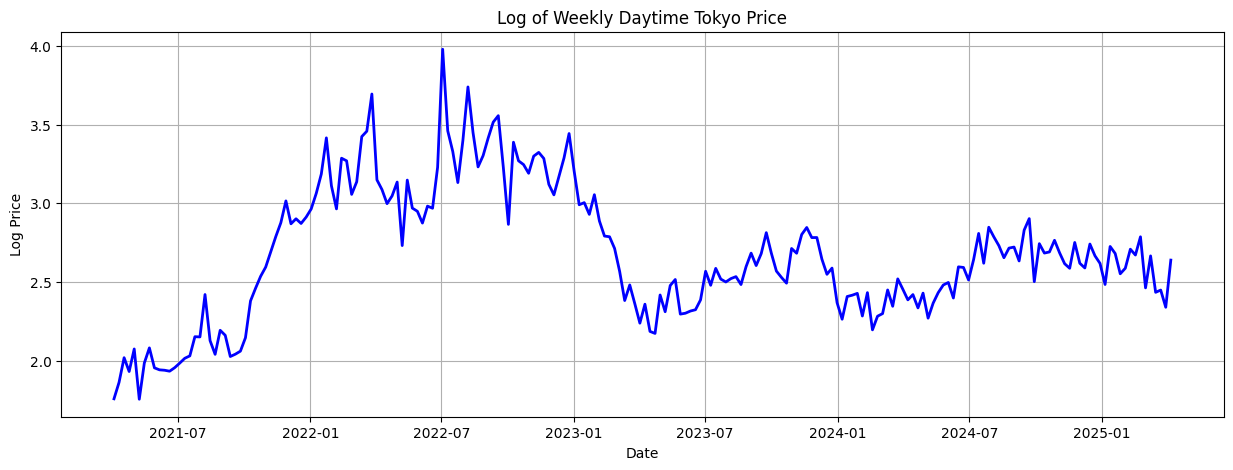

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(weekly_base.index, weekly_base["log_tokyo_price"], linewidth=2, color="blue")
ax.set_title("Log of Weekly Daytime Tokyo Price")
ax.set_xlabel("Date")
ax.set_ylabel("Log Price")
ax.grid(True)
plt.show()

In [20]:
weekly_daytime = weekly_daytime.rename(
    columns={"エリアプライス東京(円/kWh)": "tokyo_price"}
)
weekly_daytime.head()

,tokyo_price
datetime,
2021-04-04,5.603095
2021-04-11,5.997619
2021-04-18,7.768857
2021-04-25,6.017333
2021-05-02,8.294667


In [21]:
weekly_daytime = weekly_daytime.copy()
weekly_daytime["log_tokyo_price"] = np.log(weekly_daytime["tokyo_price"])
weekly_daytime.head()

,tokyo_price,log_tokyo_price
datetime,,
2021-04-04,5.603095,1.723319
2021-04-11,5.997619,1.791363
2021-04-18,7.768857,2.050123
2021-04-25,6.017333,1.794644
2021-05-02,8.294667,2.115613


In [22]:
from pathlib import Path

print(Path.cwd())

c:\Users\h20s1\workspace\paper_study\One_week_ahead_electricity_price_forecasting_using_weather_forecasts_and_its_application_to_arbitrage_in_the_forward_market_an_empirical_study_of_the_JEPX\notebooks


In [23]:
# 保存先
output_path = PROJECT_DATA_DIR / "processed/electricity/weekly_base.csv"

# ディレクトリがなければ作成
output_path.parent.mkdir(parents=True, exist_ok=True)

# CSV出力
weekly_base.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: c:\Users\h20s1\workspace\paper_study\One_week_ahead_electricity_price_forecasting_using_weather_forecasts_and_its_application_to_arbitrage_in_the_forward_market_an_empirical_study_of_the_JEPX\data\processed\electricity\weekly_base.csv


In [24]:
# 保存先
output_path = PROJECT_DATA_DIR / "processed/electricity/weekly_daytime.csv"

# ディレクトリがなければ作成
output_path.parent.mkdir(parents=True, exist_ok=True)

# CSV出力
weekly_daytime.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: c:\Users\h20s1\workspace\paper_study\One_week_ahead_electricity_price_forecasting_using_weather_forecasts_and_its_application_to_arbitrage_in_the_forward_market_an_empirical_study_of_the_JEPX\data\processed\electricity\weekly_daytime.csv


## 自己回帰係数の考察

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm

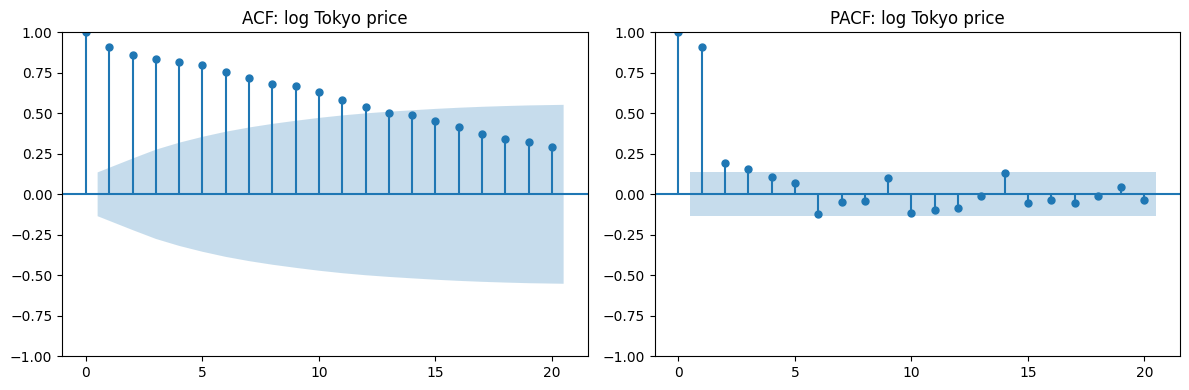

In [26]:
y = weekly_base["log_tokyo_price"].dropna()
# ACFとPACFのプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y, lags=20, ax=axes[0])
axes[0].set_title("ACF: log Tokyo price")

plot_pacf(y, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF: log Tokyo price")

plt.tight_layout()
plt.show()

1. AR(1)を推定
2. AR(p), p=1,...,8 のAIC/BIC比較
3. 選ばれたAR(p)の残差ACF確認

In [27]:
# AR(1)を推定
ar1_model = AutoReg(y, lags=1, old_names=False)
ar1_res = ar1_model.fit()

print(ar1_res.summary())

                            AutoReg Model Results                             
Dep. Variable:        log_tokyo_price   No. Observations:                  210
Model:                     AutoReg(1)   Log Likelihood                  84.255
Method:               Conditional MLE   S.D. of innovations              0.162
Date:                Sun, 13 Sep 2026   AIC                           -162.510
Time:                        20:30:41   BIC                           -152.483
Sample:                    04-11-2021   HQIC                          -158.456
                         - 04-06-2025                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2423      0.072      3.370      0.001       0.101       0.383
log_tokyo_price.L1     0.9110      0.027     34.299      0.000       0.859       0.963
                    

In [28]:
# AR(p), p=1,...,8 のAIC/BIC比較
ic_results = []

for p in range(1, 9):
    model = AutoReg(y, lags=p, old_names=False)
    res = model.fit()

    ic_results.append({"p": p, "AIC": res.aic, "BIC": res.bic, "HQIC": res.hqic})

ic_table = pd.DataFrame(ic_results)

ic_table

,p,AIC,BIC,HQIC
0,1,-162.510103,-152.483100,-158.456127
1,2,-169.108372,-155.758219,-163.710256
2,3,-171.972510,-155.308916,-165.233898
3,4,-172.759395,-152.792138,-164.683962
4,5,-170.695741,-147.434671,-161.287196
5,6,-172.089940,-145.544980,-161.352022
6,7,-169.449055,-139.630201,-157.385538
7,8,-166.410578,-133.327901,-153.025267


In [29]:
best_p_bic = int(ic_table.loc[ic_table["BIC"].idxmin(), "p"])
best_p_aic = int(ic_table.loc[ic_table["AIC"].idxmin(), "p"])

print("Best p by AIC:", best_p_aic)
print("Best p by BIC:", best_p_bic)

Best p by AIC: 4
Best p by BIC: 2


In [30]:
# BICで選んだモデルを推定
best_model = AutoReg(y, lags=best_p_bic, old_names=False)
best_res = best_model.fit()

print(best_res.summary())

                            AutoReg Model Results                             
Dep. Variable:        log_tokyo_price   No. Observations:                  210
Model:                     AutoReg(2)   Log Likelihood                  88.554
Method:               Conditional MLE   S.D. of innovations              0.158
Date:                Sun, 13 Sep 2026   AIC                           -169.108
Time:                        20:30:41   BIC                           -155.758
Sample:                    04-18-2021   HQIC                          -163.710
                         - 04-06-2025                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2013      0.072      2.788      0.005       0.060       0.343
log_tokyo_price.L1     0.7065      0.068     10.379      0.000       0.573       0.840
log_tokyo_price.L2  

<Figure size 800x400 with 0 Axes>

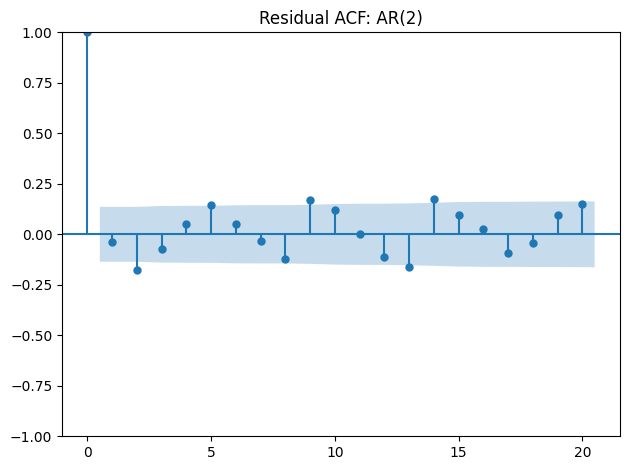

In [31]:
resid = best_res.resid

plt.figure(figsize=(8, 4))
plot_acf(resid, lags=20)
plt.title(f"Residual ACF: AR({best_p_bic})")
plt.tight_layout()
plt.show()

AR(2)で短期自己相関はかなり除去できている
が、周期的な構造が少し残っている

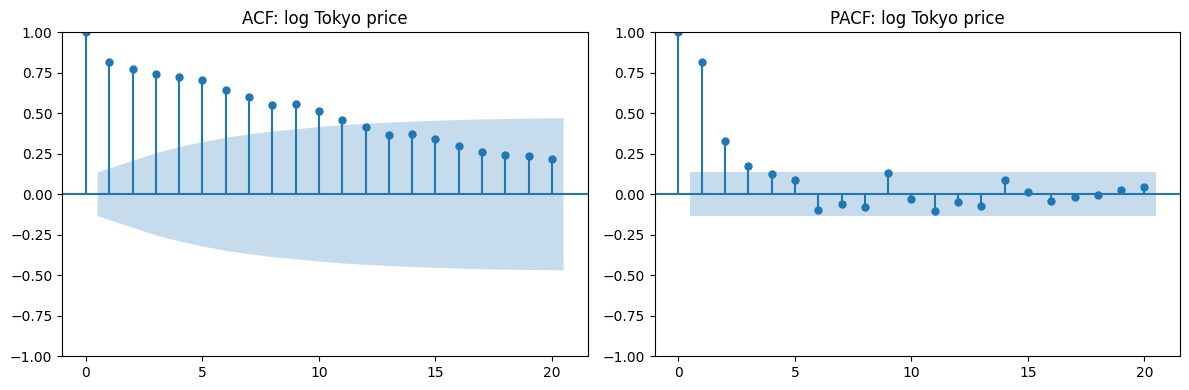

In [32]:
y = weekly_daytime["log_tokyo_price"].dropna()
# ACFとPACFのプロット
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(y, lags=20, ax=axes[0])
axes[0].set_title("ACF: log Tokyo price")

plot_pacf(y, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF: log Tokyo price")

plt.tight_layout()
plt.show()

In [33]:
# AR(p), p=1,...,8 のAIC/BIC比較
ic_results = []

for p in range(1, 9):
    model = AutoReg(y, lags=p, old_names=False)
    res = model.fit()

    ic_results.append({"p": p, "AIC": res.aic, "BIC": res.bic, "HQIC": res.hqic})

ic_table = pd.DataFrame(ic_results)

ic_table

,p,AIC,BIC,HQIC
0,1,67.242370,77.269373,71.296346
1,2,40.984410,54.334562,46.382526
2,3,36.056830,52.720424,42.795442
3,4,33.088953,53.056210,41.164385
4,5,33.426378,56.687448,42.834923
5,6,32.491123,59.036083,43.229041
6,7,34.593468,64.412321,46.656985
7,8,33.673862,66.756539,47.059173


In [34]:
best_p_bic = int(ic_table.loc[ic_table["BIC"].idxmin(), "p"])
best_p_aic = int(ic_table.loc[ic_table["AIC"].idxmin(), "p"])

print("Best p by AIC:", best_p_aic)
print("Best p by BIC:", best_p_bic)

Best p by AIC: 6
Best p by BIC: 3


In [35]:
# BICで選んだモデルを推定
best_model = AutoReg(y, lags=best_p_bic, old_names=False)
best_res = best_model.fit()

print(best_res.summary())

                            AutoReg Model Results                             
Dep. Variable:        log_tokyo_price   No. Observations:                  210
Model:                     AutoReg(3)   Log Likelihood                 -13.028
Method:               Conditional MLE   S.D. of innovations              0.258
Date:                Sun, 13 Sep 2026   AIC                             36.057
Time:                        20:30:42   BIC                             52.720
Sample:                    04-25-2021   HQIC                            42.795
                         - 04-06-2025                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2927      0.108      2.708      0.007       0.081       0.505
log_tokyo_price.L1     0.4488      0.068      6.562      0.000       0.315       0.583
log_tokyo_price.L2  

<Figure size 800x400 with 0 Axes>

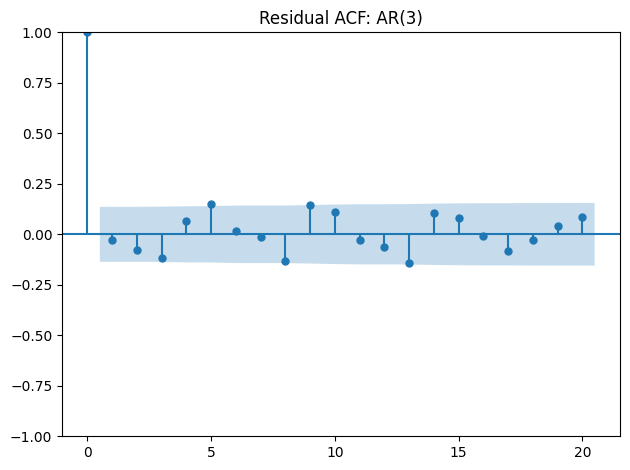

In [36]:
resid = best_res.resid

plt.figure(figsize=(8, 4))
plot_acf(resid, lags=20)
plt.title(f"Residual ACF: AR({best_p_bic})")
plt.tight_layout()
plt.show()